## CIS 635 Project

### Leveraging Data Mining to Understand and Predict Airbnb Listing Prices

#### Loading required libraries

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler,MinMaxScaler
import joblib

#### Downloading data from kaggle website

The data we are using for this project is hosted in kaggle. [U.S. Airbnb Open Data](https://www.kaggle.com/datasets/kritikseth/us-airbnb-open-data)

#### Downloading datasets in csv format

In [ ]:
#Path to the dataset
path = kagglehub.dataset_download("kritikseth/us-airbnb-open-data")


Using Colab cache for faster access to the 'us-airbnb-open-data' dataset.


In [ ]:
#Connecting to files in path
csv_path1 = os.path.join(path, "AB_US_2020.csv")
csv_path2 = os.path.join(path, "AB_US_2023.csv")
#Loading the data from CSV files
df1 = pd.read_csv(csv_path1)
df2 = pd.read_csv(csv_path2)
#Previewing the two datasets
print(df1.describe())
print(df2.describe())

/tmp/ipython-input-3826004644.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(csv_path1)
/tmp/ipython-input-3826004644.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(csv_path2)


                 id       host_id       latitude      longitude  \
count  2.260300e+05  2.260300e+05  226030.000000  226030.000000   
mean   2.547176e+07  9.352385e+07      35.662829    -103.220662   
std    1.317814e+07  9.827422e+07       6.849855      26.222091   
min    1.090000e+02  2.300000e+01      18.920990    -159.714900   
25%    1.515890e+07  1.399275e+07      32.761783    -118.598115   
50%    2.590916e+07  5.138266e+07      37.261125     -97.817200   
75%    3.772624e+07  1.497179e+08      40.724038     -76.919323   
max    4.556085e+07  3.679176e+08      47.734620     -70.995950   

               price  minimum_nights  number_of_reviews  reviews_per_month  \
count  226030.000000    2.260300e+05      226030.000000       177428.00000   
mean      219.716529    4.525490e+02          34.506530            1.43145   
std       570.353609    2.103376e+05          63.602914            1.68321   
min         0.000000    1.000000e+00           0.000000            0.01000   
25%   

In [ ]:
#checking the length of columns in df1 and df2
print(f'Columns in df1 = {len(df1.columns)}')
print(f'Columns in df2 = {len(df2.columns)}')

Columns in df1 = 17
Columns in df2 = 18


In [ ]:
#Selecting columns common in both df1 and df2 before concatenating the dataframes
df1_cols = set(df1.columns)
df2_cols = set(df2.columns)

#Common columns
common = df1_cols & df2_cols
unique_to_df2 = df2_cols - df1_cols
print("Common columns:", common)
print("Columns unique to df2:", unique_to_df2)

Common columns: {'room_type', 'number_of_reviews', 'neighbourhood_group', 'reviews_per_month', 'name', 'host_id', 'price', 'id', 'neighbourhood', 'minimum_nights', 'latitude', 'calculated_host_listings_count', 'city', 'availability_365', 'longitude', 'last_review', 'host_name'}
Columns unique to df2: {'number_of_reviews_ltm'}


In [ ]:
# Finding unique columns in df1 (columns that are in df1 but not in df2)
unique_df1 = df1_cols - df2_cols
print("\nColumns unique to df1:", unique_df1)
# Finding unique columns in df2 (columns that are in df2 but not in df1)
unique_df2 = df2_cols - df1_cols
print("\nColumns unique to df2:", unique_df2)


Columns unique to df1: set()

Columns unique to df2: {'number_of_reviews_ltm'}


In [ ]:
#selecting only common columns in df2 to merge df1.
df2 = df2[list(common)]
len(df2.columns)

17

In [ ]:
#concatenating df1 and df2
joined_df = pd.concat([df1, df2], axis=0, ignore_index=True)
merged_df = joined_df.copy()

In [ ]:
joined_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,38585,Charming Victorian home - twin beds + breakfast,165529,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,80905,French Chic Loft,427027,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,320564,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.57864,-82.59578,Entire home/apt,90,1,267,22/09/20,2.39,5,0,Asheville
4,160594,Historic Grove Park,769252,Elizabeth,NaN,28801,35.61442,-82.54127,Private room,125,30,58,19/10/15,0.52,1,0,Asheville


In [ ]:
joined_df.shape

(458177, 17)

The dataframe consists of 458177 entries and 17 variables.

In [ ]:
#Checking the data types of various variables in the dataframe.
print(joined_df.info(show_counts=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458177 entries, 0 to 458176
Data columns (total 17 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   id                              int64  
 1   name                            object 
 2   host_id                         int64  
 3   host_name                       object 
 4   neighbourhood_group             object 
 5   neighbourhood                   object 
 6   latitude                        float64
 7   longitude                       float64
 8   room_type                       object 
 9   price                           int64  
 10  minimum_nights                  int64  
 11  number_of_reviews               int64  
 12  last_review                     object 
 13  reviews_per_month               float64
 14  calculated_host_listings_count  int64  
 15  availability_365                int64  
 16  city                            object 
dtypes: float64(3), int64(7), obje

#### Checking the number of missing values for every column in joined df

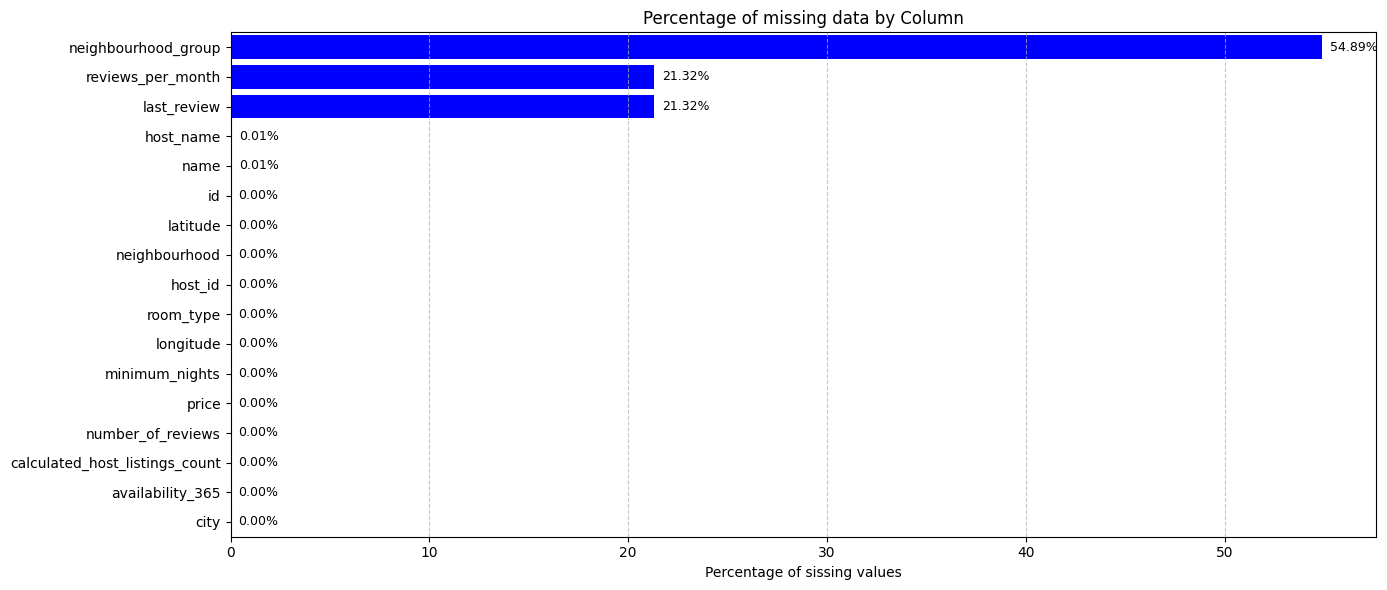

In [ ]:
#Visualizing missing data.
missing_counts = joined_df.isnull().sum()
missing_df = pd.DataFrame({'column': missing_counts.index,
                           'missing_percent': (missing_counts.values/len(joined_df))*100
                           })
missing_df = missing_df.sort_values(by='missing_percent', ascending=False)
plt.figure(figsize=(14, 6))
bars = plt.barh(missing_df['column'], missing_df['missing_percent'], color='blue')
plt.ylim(-0.5, len(missing_df['column']) - 0.5)
plt.xlabel('Percentage of sissing values')
plt.title('Percentage of missing data by Column')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
for bar, percent in zip(bars, missing_df['missing_percent']):
    plt.text(percent + 0.4, bar.get_y() + bar.get_height()/2,
             f'{percent:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Neighbourhood_group variable has the highest number of missing values at 54.89% of the total entries for neighbourhood_group. Reviews_per_month and last_review both have 21.32% of missing values. host_name and name have 0.01% of missing values which is negligible.

In [ ]:
cleaned_df = joined_df.drop('neighbourhood_group', axis=1)
cleaned_df = cleaned_df.dropna()

Dropping missing values in reviews_per_month, last_review, host_name and name because they are negligible considering the size of our dataset.

Dropping neighbourhood_group because it has more than 50% of missing data which cannot be estimated or filled.

### Checking for noise in the dataframe

#### Checking for noise in minimum nights variable


price Descriptive Statistics:
count    177387.000000
mean        184.814265
std         128.282800
min          11.000000
25%          94.000000
50%         149.000000
75%         240.000000
max         699.000000
Name: price, dtype: float64

minimum_nights Descriptive Statistics:
count    177387.000000
mean          3.137248
std           2.005670
min           2.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          14.000000
Name: minimum_nights, dtype: float64

availability_365 Descriptive Statistics:
count    177387.000000
mean        160.248220
std         131.051299
min           0.000000
25%          30.000000
50%         146.000000
75%         293.000000
max         365.000000
Name: availability_365, dtype: float64

calculated_host_listings_count Descriptive Statistics:
count    177387.000000
mean         10.327938
std          29.271368
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         35

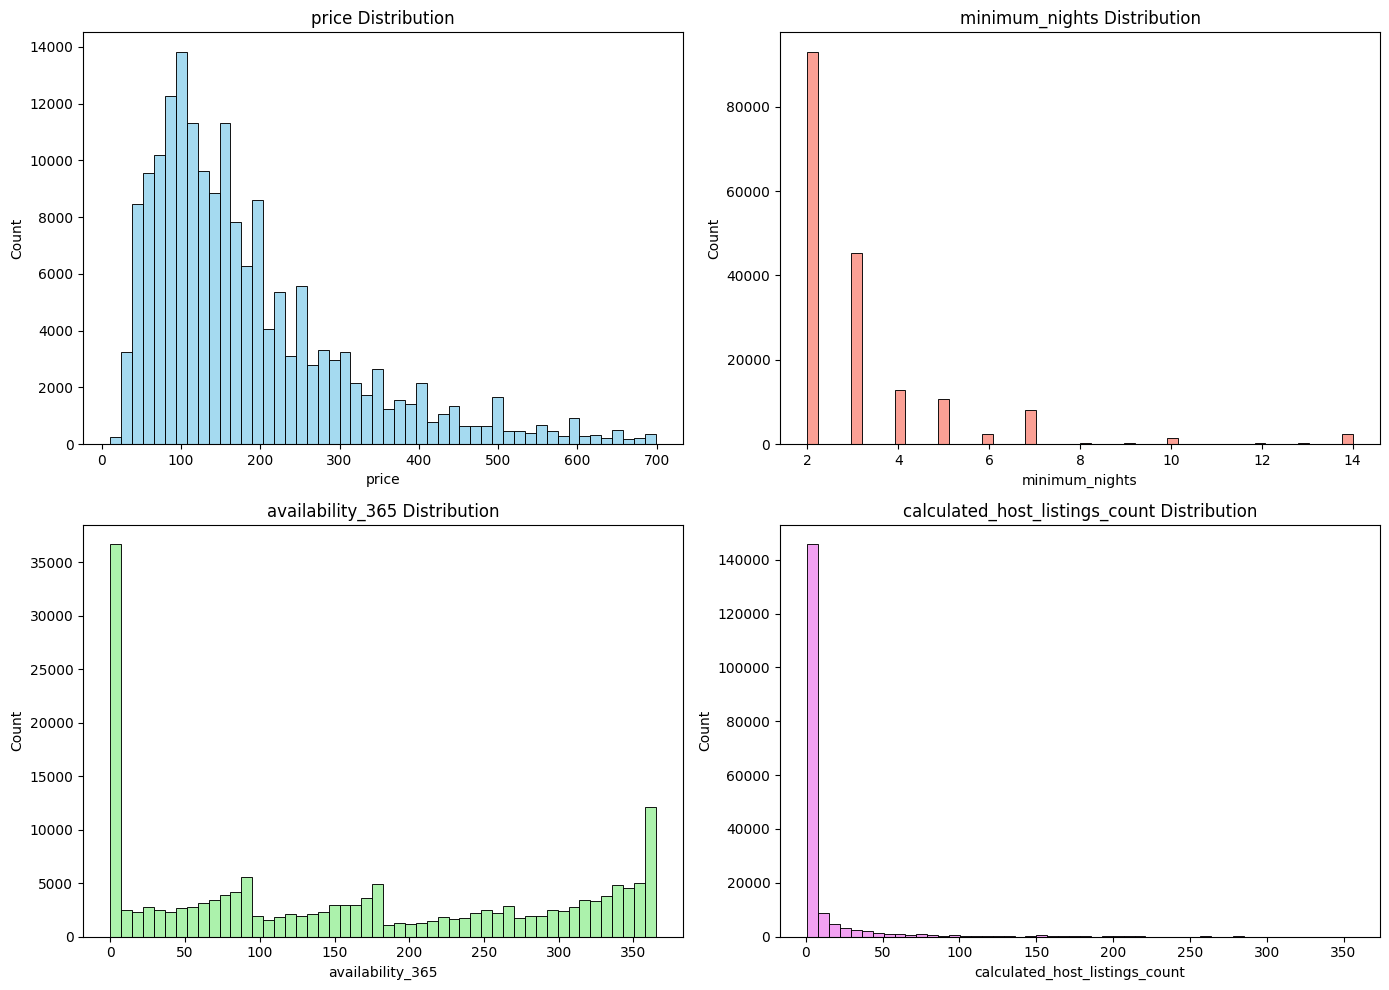

In [ ]:
#Univariate analysis of the variables
num_cols = ['price', 'minimum_nights', 'availability_365', 'calculated_host_listings_count']
cleaned_df_filtered = cleaned_df.copy()
#Price filter
cleaned_df_filtered = cleaned_df_filtered[(cleaned_df_filtered['price'] < 700) & (cleaned_df_filtered['price'] > 10)]
#Minimum nights filter
cleaned_df_filtered = cleaned_df_filtered[(cleaned_df_filtered['minimum_nights'] > 1) & (cleaned_df_filtered['minimum_nights'] <= 14)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['skyblue', 'salmon', 'lightgreen', 'violet']

for i, col in enumerate(num_cols):
    sns.histplot(cleaned_df_filtered[col], bins=50, kde=False, ax=axes[i], color=colors[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Print descriptive stats
    print(f"\n{col} Descriptive Statistics:")
    print(cleaned_df_filtered[col].describe())

plt.tight_layout()
plt.show()

#### Outlier detection

In [ ]:
# Remove outliers using price and minimum_nights filters
cleaned_df_filtered = cleaned_df[(cleaned_df['price'] < 700) & (cleaned_df['price'] > 10)]
cleaned_df_filtered = cleaned_df_filtered[(cleaned_df_filtered['minimum_nights'] > 1) & (cleaned_df_filtered['minimum_nights'] <= 14)]

# Z-score based outlier removal
cols_to_check = ['price', 'minimum_nights', 'availability_365', 'calculated_host_listings_count']
z_scores = np.abs(zscore(cleaned_df[cols_to_check]))
mask = (z_scores < 2).all(axis=1)
df_cleaned_1 = cleaned_df[mask]

In [ ]:
# Boxplot to visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['skyblue', 'salmon', 'lightgreen', 'violet']


for i, col in enumerate(num_cols):
sns.boxplot(y=cleaned_df_filtered[col], ax=axes[i], color=colors[i])
axes[i].set_title(f'{col} Outlier Detection')
axes[i].set_xlabel('')
axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned_1.shape

(348178, 16)

In [ ]:
df_capped = df_cleaned_1[(df_cleaned_1['price'] > 10) & (df_cleaned_1['price'] < 700) & (df_cleaned_1['minimum_nights'] > 1) & (df_cleaned_1['minimum_nights'] <= 14)].copy()

### Feature engineering

Engineering an new variable named neighbourhood_tier which shows how negihbourhoods are grouped according to their proximity to the city and their price

In [ ]:
# Feature Engineering
df_engineered = df_capped.copy()

# Computing city centers
city_centers = df_engineered.groupby('city')[['latitude', 'longitude']].mean().rename(columns={'latitude': 'city_lat', 'longitude': 'city_lon'})
df_engineered = df_engineered.merge(city_centers, on='city')
df_engineered['distance_to_center'] = np.sqrt((df_engineered['latitude'] - df_engineered['city_lat'])**2 + (df_engineered['longitude'] - df_engineered['city_lon'])**2)

# Normalizing price and distance variables
scaler = MinMaxScaler()
df_engineered[['price_scaled', 'distance_scaled']] = scaler.fit_transform(df_engineered[['price', 'distance_to_center']])

# Creating the neighbourhood score and tiers
df_engineered['neighbourhood_score'] = df_engineered['price_scaled'] - df_engineered['distance_scaled']
labels = ['Midtown', 'Downtown', 'Central Business District']
df_engineered['neighbourhood_tier'] = pd.qcut(df_engineered['neighbourhood_score'], q=3, labels=labels)

# Retaining the relevant columns
columns_to_keep = df_capped.columns.tolist() + ['neighbourhood_tier']
columns_to_keep = [c for c in columns_to_keep if c in df_engineered.columns]
df_engineered = df_engineered[columns_to_keep]

### Data visualization

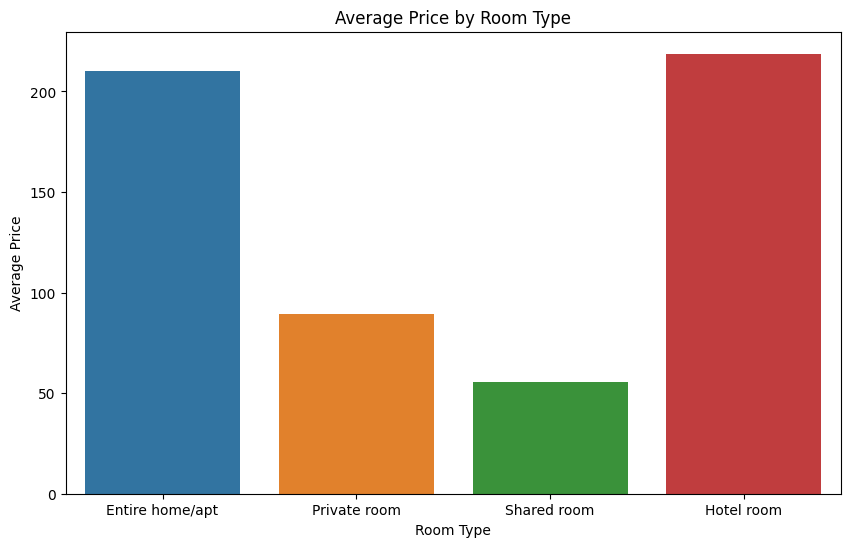

/tmp/ipython-input-5545850.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order=df_engineered.groupby('neighbourhood_tier')['price'].mean().sort_values(ascending=False).index,


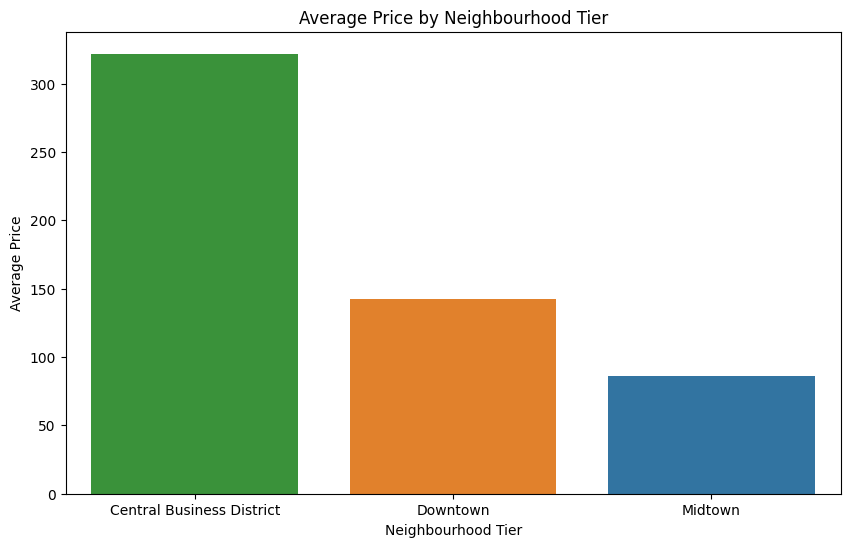

In [ ]:
# Visualizations of average price by room type and average price by neighborhood tier
plt.figure(figsize=(10,6), dpi=100)
sns.barplot(x='room_type', y='price', data=df_capped, hue='room_type', errorbar=None)
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.title('Average Price by Room Type')
plt.show()

plt.figure(figsize=(10,6), dpi=100)
sns.barplot(
x='neighbourhood_tier',
y='price',
data=df_engineered,
hue='neighbourhood_tier',
order=df_engineered.groupby('neighbourhood_tier')['price'].mean().sort_values(ascending=False).index,
errorbar=None
)
plt.xlabel('Neighbourhood Tier')
plt.ylabel('Average Price')
plt.title('Average Price by Neighbourhood Tier')
plt.show()

### Data preparation for modelling

In [ ]:
# Data preparation for modeling
X = df_engineered.drop(columns=['price'])
y = np.log1p(df_engineered['price'])

categorical_cols = ['room_type', 'city', 'neighbourhood_tier']
log_cols = ['minimum_nights', 'reviews_per_month']
numeric_cols = ['minimum_nights', 'reviews_per_month']

categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
log_transformer = FunctionTransformer(np.log1p, validate=False)
scaler = StandardScaler()

preprocessor = ColumnTransformer(
transformers=[
('cat', categorical_transformer, categorical_cols),
('log', log_transformer, log_cols),
('num', scaler, numeric_cols)
],
remainder='drop'
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

#### Implementing a linear regression model

In [ ]:
# Linear regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
rmse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"Linear Regression RMSE: {rmse_lin:.4f}")
print(f"Linear Regression R² Score: {r2_lin:.4f}")

Linear Regression RMSE: 0.0879
Linear Regression R² Score: 0.8016


#### Implementing a Random Forest Model

In [ ]:
# Random forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest R² Score: {r2_rf:.4f}")

Random Forest RMSE: 0.1002
Random Forest R² Score: 0.7737


In [ ]:
# Randomn Forest Grid Search
# Defining parameters for grid search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Creating and fitting a GridSearch
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Getting best model and parameters
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

# Making predictions
y_pred = best_rf.predict(X_test)

# Convertting back from log scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

# Calculating metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)

print(f"\nRandom Forest Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

# Saving the best model
joblib.dump(best_rf, 'best_random_forest_model.pkl')
print("Best model saved as 'best_random_forest_model.pkl'")

# Saving the entire GridSearch object
joblib.dump(grid_search, 'grid_search_results.pkl')
print("GridSearch results saved as 'grid_search_results.pkl'")

# Saving the best parameters to a text file
with open('best_parameters.txt', 'w') as f:
    f.write("Best Random Forest Parameters:\n")
    for key, value in best_params.items():
        f.write(f"{key}: {value}\n")
    f.write(f"\nBest R² Score: {r2:.4f}")
print("Best parameters saved as 'best_parameters.txt'")

# Compare with neural network
try:
    print(f"\nComparison:")
    print(f"Random Forest R²: {r2:.4f}")
    print(f"Neural Network R²: {nn_r2:.4f}")

    if r2 > nn_r2:
        improvement = ((r2 - nn_r2) / nn_r2) * 100
        print(f"Random Forest outperforms by: +{improvement:.2f}%")
    else:
        improvement = ((nn_r2 - r2) / r2) * 100
        print(f"Neural Network outperforms by: +{improvement:.2f}%")
except NameError:
    print("\n(Neural network results not available for comparison)")

# Feature importance
feature_importance = best_rf.feature_importances_

#Getting feature names from preprocessor
try:
    feature_names = []
    # Categorical features
    if hasattr(pipeline.named_steps['preprocessor'].named_transformers_['cat'], 'get_feature_names_out'):
        cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
        feature_names.extend(cat_features)
    #Log and numeric features
    feature_names.extend(log_cols)
    feature_names.extend(numeric_cols)

    # Creating feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)

    print(f"\nTop 10 Most Important Features:")
    print(importance_df.head(10))

    # Saving feature importance to CSV
    importance_df.to_csv('feature_importance.csv', index=False)

    # Plotting feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'].head(10)[::-1], importance_df['importance'].head(10)[::-1])
    plt.xlabel('Feature Importance')
    plt.title('Top 10 most Important Features for Random Forest')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not get feature names: {e}")
    print(f"Feature importance array shape: {feature_importance.shape}")

# Plotting predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_pred_original.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Random Forest: Actual vs Predicted Prices\nR²: {r2:.4f}')
plt.show()

NameError: name 'RandomForestRegressor' is not defined